<a href="https://colab.research.google.com/github/Ali8089/Data_Science-and-ML/blob/Data_Cleaning/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Feature Engineering

Feature engineering is the process of using domain knowledge to extract features from raw data. These features can be used to improve the performance of ML model.

Componenets of Feature Engineering:
1. Feature Transformation:


*   Missing values
*   Handling Categorical Features

*   Outlier Detection
*   Feature Scaling



2. Feature Construction
3. Feature Selection
4. Feature Extraction







## Feature Scaling:
Feature scaling is a preprocessing step in machine learning used to standardize the range of independent variables or features in a dataset

Types of Feature Scaling:
1. Standardization
2. Normalization

Why is it Necessary:
9
Machine learning algorithms are mathematically sensitive to the magnitude of data. If one feature (e.g., income measured in tens of thousands) is much larger than another (e.g., age measured in tens), algorithms that rely on distance calculations (like K-Nearest Neighbors or Support Vector Machines) or gradient descent (like Neural Networks and Linear Regression) will unfairly weigh the larger feature, leading to slow training times and skewed predictions.

##Standardization (Z-normalization)
Converts the data to mean = 0 and standard deviation = 1.

Formula : z = (x - u)/std

1. Use Standard Scaler in Scikit Learn
2. First do train/test split
3. Fit to only train set
4. Apply to both test and train













In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/insurance_data - insurance_data.csv')

conditions = (
    ((df['bloodpressure'] > 100) | (df['smoker'] == 'Yes') | (df['diabetic'] == 'Yes')),
    ((df['bloodpressure'] < 100) | (df['smoker'] == 'No') | (df['diabetic'] == 'No'))

)
choices = ['good','bad']

df['health_score'] = np.select(conditions,choices,default='avg')
df

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,health_score
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87,good
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51,bad
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94,good
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40,bad
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01,bad
...,...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40,good
1336,1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07,good
1337,1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40,good
1338,1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87,good


In [4]:
df.isnull().sum()

,0
index,0
PatientID,0
age,5
gender,0
bmi,0
bloodpressure,0
diabetic,0
children,0
smoker,0
region,3


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='claim'), df['claim'], test_size=0.1, random_state=0)

In [6]:
X_train['bloodpressure']


,bloodpressure
39,100
792,83
452,92
1,87
529,83
...,...
763,80
835,95
1216,131
559,83


In [7]:
from sklearn.preprocessing import StandardScaler
s_scaler = StandardScaler()
s_scaler.fit(X_train[['bloodpressure']])
X_train['bloodpressure'] = s_scaler.transform(X_train[['bloodpressure']])

In [8]:
X_train['bloodpressure']


,bloodpressure
39,0.543710
792,-0.975389
452,-0.171160
1,-0.617954
529,-0.975389
...,...
763,-1.243465
835,0.096916
1216,3.313832
559,-0.975389


In [9]:
X_train['bmi']

,bmi
39,39.8
792,32.8
452,30.8
1,30.1
529,27.7
...,...
763,33.6
835,31.8
1216,36.9
559,34.6


##MinMax Scaler: Standardizes data into a specific range
# FORMULLA(0-1) RANGE:
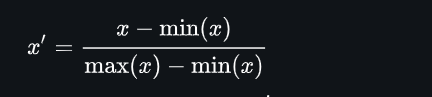

#FORUMLA 2( SPECIFIC RANGE [a,b]):
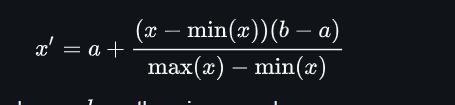

In [10]:
#MinMax Scaler (0-1)
# FORMULLA : X =
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler() ## for a specific range  ----- min_max_scaler = MinMaxScaler(feature_range=(a,b))
min_max_scaler.fit(X_train[['bmi']])
X_train['bmi'] = min_max_scaler.transform(X_train[['bmi']])


In [11]:
X_train['bmi']

,bmi
39,0.641509
792,0.452830
452,0.398922
1,0.380054
529,0.315364
...,...
763,0.474394
835,0.425876
1216,0.563342
559,0.501348


In [12]:
X_train['bmi'].describe()

,bmi
count,1206.000000
mean,0.395882
std,0.164302
min,0.000000
25%,0.277628
50%,0.388140
75%,0.506739
max,1.000000


In [13]:
X_train['age']

,age
39,49.0
792,47.0
452,56.0
1,24.0
529,46.0
...,...
763,38.0
835,33.0
1216,34.0
559,54.0


In [14]:
X_train['age'].describe()

,age
count,1202.000000
mean,37.990017
std,11.077273
min,18.000000
25%,29.000000
50%,37.000000
75%,46.000000
max,60.000000


##ROBUST SCALER:
It centers data by subtracting the median and scales it using the interquartile range (IQR), effectively ignoring extreme values that can distort other scalers

#FORMULA:
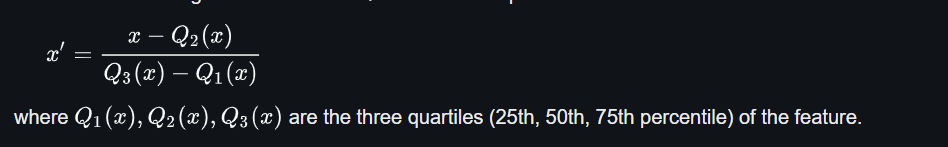

(It is generally used when the data has outliers)

In [15]:
from sklearn.preprocessing import RobustScaler
robust_scaler = RobustScaler()
robust_scaler.fit(X_train[['age']])
X_train['age'] = robust_scaler.transform(X_train[['age']])


In [16]:
X_train['age']

,age
39,0.705882
792,0.588235
452,1.117647
1,-0.764706
529,0.529412
...,...
763,0.058824
835,-0.235294
1216,-0.176471
559,1.000000


In [17]:
X_train['age'].describe()

,age
count,1202.000000
mean,0.058236
std,0.651604
min,-1.117647
25%,-0.470588
50%,0.000000
75%,0.529412
max,1.352941


##Label/String Encoding
Most machine learning algorithims cannot understand strings and categorical data, hence strings and categorical data need to be converted to numerical data before being passed to ML algorithms.

There are mainly two types of categorical data:
1. Nominal Data: categories have no relation with each other
2. Ordinal Data: categories have relation with each other.

For converting each type of categorical data we have different type of encodings


Nominal Data >>>>>> One-Hot Encoding (OHE)

Ordinal Data >>>>>> Ordinal Encoding

In [18]:
X_train['health_score']

,health_score
39,good
792,bad
452,good
1,bad
529,bad
...,...
763,good
835,bad
1216,good
559,bad


In [19]:
# Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['bad','good']])
oe.fit(X_train[['health_score']])
X_train['health_score'] = oe.transform(X_train[['health_score']])

In [20]:
X_train['health_score']

,health_score
39,1.0
792,0.0
452,1.0
1,0.0
529,0.0
...,...
763,1.0
835,0.0
1216,1.0
559,0.0


In [21]:
X_train[['region']]

,region
39,southeast
792,northwest
452,southeast
1,southeast
529,northwest
...,...
763,northwest
835,northwest
1216,southeast
559,northwest


In [22]:
#One-Hot Encoding
# OHE using Pandas

df['region'].value_counts()


,count
region,
southeast,443
northwest,349
southwest,314
northeast,231


In [23]:
pd.get_dummies(df,columns=['region'])

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,claim,health_score,region_northeast,region_northwest,region_southeast,region_southwest
0,0,1,39.0,male,23.2,91,Yes,0,No,1121.87,good,False,False,True,False
1,1,2,24.0,male,30.1,87,No,0,No,1131.51,bad,False,False,True,False
2,2,3,NaN,male,33.3,82,Yes,0,No,1135.94,good,False,False,True,False
3,3,4,NaN,male,33.7,80,No,0,No,1136.40,bad,False,True,False,False
4,4,5,NaN,male,34.1,100,No,0,No,1137.01,bad,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,Yes,0,Yes,55135.40,good,False,True,False,False
1336,1336,1337,59.0,female,38.1,120,No,1,Yes,58571.07,good,True,False,False,False
1337,1337,1338,30.0,male,34.5,91,Yes,3,Yes,60021.40,good,False,True,False,False
1338,1338,1339,37.0,male,30.4,106,No,0,Yes,62592.87,good,False,False,True,False


In [24]:
#drop one category to prevent Multicollinearity
pd.get_dummies(df,columns=['region'],drop_first=True)


,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,claim,health_score,region_northwest,region_southeast,region_southwest
0,0,1,39.0,male,23.2,91,Yes,0,No,1121.87,good,False,True,False
1,1,2,24.0,male,30.1,87,No,0,No,1131.51,bad,False,True,False
2,2,3,NaN,male,33.3,82,Yes,0,No,1135.94,good,False,True,False
3,3,4,NaN,male,33.7,80,No,0,No,1136.40,bad,True,False,False
4,4,5,NaN,male,34.1,100,No,0,No,1137.01,bad,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,Yes,0,Yes,55135.40,good,True,False,False
1336,1336,1337,59.0,female,38.1,120,No,1,Yes,58571.07,good,False,False,False
1337,1337,1338,30.0,male,34.5,91,Yes,3,Yes,60021.40,good,True,False,False
1338,1338,1339,37.0,male,30.4,106,No,0,Yes,62592.87,good,False,True,False


In [25]:
#One-Hot Encoding using scikit learn
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first',sparse_output=False,dtype=np.int32)
ohe.fit(X_train[['region']])
X_train_new = ohe.transform((X_train[['region']]))
np.hstack((X_train.values,X_train_new))

array([[39, 40, 0.7058823529411765, ..., 1, 0, 0],
       [792, 793, 0.5882352941176471, ..., 0, 0, 0],
       [452, 453, 1.1176470588235294, ..., 1, 0, 0],
       ...,
       [1216, 1217, -0.17647058823529413, ..., 1, 0, 0],
       [559, 560, 1.0, ..., 0, 0, 0],
       [684, 685, 1.1176470588235294, ..., 0, 0, 0]], dtype=object)

In [26]:
#SPARSE MATRIX
ohe = OneHotEncoder(drop='first',sparse_output=True,dtype=np.int32)
ohe.fit(X_train[['region']])
ohe.transform((X_train[['region']]))

<Compressed Sparse Row sparse matrix of dtype 'int32'
	with 1001 stored elements and shape (1206, 4)>

In [27]:
#ARRAY/ NO SPARSE MATRIX
ohe = OneHotEncoder(drop='first',sparse_output=False,dtype=np.int32)
ohe.fit(X_train[['region']])
ohe.transform((X_train[['region']]))

array([[0, 1, 0, 0],
       [1, 0, 0, 0],
       [0, 1, 0, 0],
       ...,
       [0, 1, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0]], dtype=int32)

##Handling Mixed Data
Sometimes data is mixed, numerical and categorical are together, in this case to perform anaylsis and improve the performance of the model we must seperate numercial and categorical data.

Two approaches:
1. if the data is like this: B5,C23,D41 (One ore more character followed by a number) then we seperate the two in two different columns

2. If the is totally random column that contains both numbers and the categorical data seperately like (7,3,1,AB,4) then again we create two columns but this time  we replace the other column with NAN values.

In [214]:
## Case 1 one Titanic DataSet:
df = pd.read_csv('/content/titanic (1).csv')
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [215]:
df['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

In [236]:
#pd.numeric is a pandas function to convert the column into a numerical column
# it takes 3 parameters, 1) target column, 2) errors = 'coerce' meanas if there are any other datatypes ignore them and downcast decides the final datatype
# but if there are string values so they will be replaced by NaN and downcast won't work  in this cae we use astype in the end with the a special dtype
# this dtype is Int64 which automatically handles the missing values

##Extract numerical part
df['number_numerical'] =pd.to_numeric(df['number'],errors='coerce').astype('Int64')

#Extract Categorical part
df['number_categorical'] = np.where(df['number_numerical'].isnull(),df['number'],np.nan)


In [237]:
# See the seperated columns
df.head()

,Cabin,Ticket,number,Survived,Numerical,number_numerical,number_categorical
0,NaN,A/5 21171,5,0,True,5,NaN
1,C85,PC 17599,3,1,True,3,NaN
2,NaN,STON/O2. 3101282,6,1,True,6,NaN
3,C123,113803,3,1,True,3,NaN
4,NaN,373450,A,0,False,<NA>,A


In [238]:
### Case 2 one Titanic DataSet:

df['Cabin'].unique()


array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [249]:
import re
df['Cabin_Cat'] = df['Cabin'].str.extract(r'([A-Z])') #extract category
df['Cabin_Num'] = df['Cabin'].str.extract(r'(\d+)') #extract number


,Cabin,Ticket,number,Survived,Numerical,number_numerical,number_categorical,Cabin_Cat,Cabin_Num
0,NaN,A/5 21171,5,0,True,5,NaN,NaN,NaN
1,C85,PC 17599,3,1,True,3,NaN,C,85
2,NaN,STON/O2. 3101282,6,1,True,6,NaN,NaN,NaN
3,C123,113803,3,1,True,3,NaN,C,123
4,NaN,373450,A,0,False,<NA>,A,NaN,NaN
...,...,...,...,...,...,...,...,...,...
886,NaN,211536,3,0,True,3,NaN,NaN,NaN
887,B42,112053,3,1,True,3,NaN,B,42
888,NaN,W./C. 6607,1,0,True,1,NaN,NaN,NaN
889,C148,111369,2,1,True,2,NaN,C,148


In [250]:
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [253]:
#Extract number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'],
                                   errors='coerce').astype('Int64')
#Extract cateogry
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan,
                              df['ticket_cat'])

df.head(20)

,Cabin,Ticket,number,Survived,Numerical,number_numerical,number_categorical,Cabin_Cat,Cabin_Num,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,True,5,NaN,NaN,NaN,21171,A/5
1,C85,PC 17599,3,1,True,3,NaN,C,85,17599,PC
2,NaN,STON/O2. 3101282,6,1,True,6,NaN,NaN,NaN,3101282,STON/O2.
3,C123,113803,3,1,True,3,NaN,C,123,113803,NaN
4,NaN,373450,A,0,False,<NA>,A,NaN,NaN,373450,NaN
5,NaN,330877,2,0,True,2,NaN,NaN,NaN,330877,NaN
6,E46,17463,2,0,True,2,NaN,E,46,17463,NaN
7,NaN,349909,5,0,True,5,NaN,NaN,NaN,349909,NaN
8,NaN,347742,1,1,True,1,NaN,NaN,NaN,347742,NaN
9,NaN,237736,A,1,False,<NA>,A,NaN,NaN,237736,NaN


#COLUMN TRANSOFRMER:
The ColumnTransformer in scikit-learn is a tool used to apply different preprocessing steps to different columns of a dataset. It allows you to selectively scale numerical features, encode categorical columns, and handle missing values within a single, unified object.

In [28]:
#COLUMN TRANSFORMER (APPLYING MULTIPLE TRANSFROMATIONS AT ONCE)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

transformer = ColumnTransformer(transformers=[
    ('tf1',SimpleImputer(),['age']),
    ('tf2', OneHotEncoder(drop='first',sparse_output=False,dtype=np.int32),['gender']),
    ('tf3',StandardScaler(),['bmi']),
    ('tf4',StandardScaler(),['bloodpressure']),
    ('tf5',OrdinalEncoder(categories=[['No','Yes']]),['diabetic']),
    ('tf6',OrdinalEncoder(categories=[['No','Yes']]),['smoker']),
    ('tf7',OrdinalEncoder(categories=[['bad','good','avg']]),['health_score']),
    ('tf8', OneHotEncoder(drop='first',sparse_output=False,dtype=np.int32),['region']),
])

## Data Transformation


In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv('train.csv', usecols= ['Age','Fare','Survived'])

### 2. Loading the Dataset

We load the `train.csv` file into a pandas DataFrame. For this analysis, we are only interested in the 'Age', 'Fare', and 'Survived' columns, so we use the `usecols` parameter to load only these specific columns to keep the DataFrame concise.

In [ ]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


### 3. Displaying the DataFrame

Displaying the DataFrame `df` allows us to quickly inspect the loaded data, including the columns, their types, and the first few rows. This helps in understanding the data structure and identifying any immediate issues.

In [ ]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


### 4. Checking for Missing Values

It's crucial to identify missing values (NaNs) in the dataset, as they can interfere with model training. `df.isnull().sum()` provides a concise summary of the number of missing values for each column. Here, we see that 'Age' has a significant number of missing entries.

In [ ]:
x = df.iloc[:,1:3]
y = df.iloc[:,0]

### 5. Separating Features and Target Variable

We separate the dataset into features (`x`) and the target variable (`y`). 'Survived' is our target variable, and 'Age' and 'Fare' are our features. `iloc` is used for integer-location based indexing to select the columns.

In [ ]:
X_train,X_test, Y_train, Y_test = train_test_split(x,y, test_size=0.1,random_state=42)


### 6. Splitting Data into Training and Test Sets

To properly evaluate our models, we split the data into training and testing sets using `train_test_split`. This ensures that the model is trained on one part of the data and evaluated on unseen data, preventing overfitting. `test_size=0.1` means 10% of the data will be used for testing, and `random_state=42` ensures reproducibility.

In [ ]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer()
X_train['Age'] = impute.fit_transform(X_train[['Age']])
X_test['Age'] = impute.fit_transform(X_test[['Age']])

### 7. Imputing Missing 'Age' Values

Before training any model, we need to handle the missing values in the 'Age' column. We use `SimpleImputer` to replace these missing values with the mean of the 'Age' column. It's important to fit the imputer on the training data (`X_train`) and then transform both training and test data to avoid data leakage.

In [ ]:
from sklearn.preprocessing import RobustScaler

r_scaler = RobustScaler()
X_train['Fare'] = r_scaler.fit_transform(X_train[['Fare']])
X_test['Fare'] = r_scaler.fit_transform(X_test[['Fare']])


### 8. Scaling the 'Fare' Feature

'Fare' is a numerical feature with a potentially wide range of values. Scaling helps normalize the feature, which can improve the performance of many machine learning algorithms. `RobustScaler` is chosen here because it's less prone to outliers than `StandardScaler` or `MinMaxScaler`, as it uses the interquartile range (IQR).

In [ ]:
X_train['Fare'].skew()

np.float64(4.901677377614406)

### 9. Checking Skewness of 'Fare'

Skewness measures the asymmetry of the probability distribution of a real-valued random variable about its mean. A high positive skewness (like the one observed for 'Fare') indicates a long tail to the right, meaning there are many lower values and fewer extremely high values. This non-normal distribution can negatively impact models that assume normality.

<Axes: ylabel='Density'>

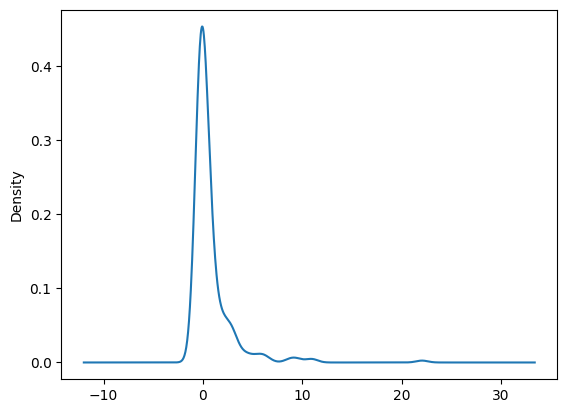

In [ ]:
X_train['Fare'].plot(kind='kde')

### 10. Visualizing 'Fare' Distribution with KDE Plot

A Kernel Density Estimate (KDE) plot visualizes the probability density function of a continuous variable. This plot for 'Fare' clearly shows a heavily right-skewed distribution, with a high density of values at the lower end and a long tail extending towards higher values. This visual confirms the high skewness calculated earlier.

In [ ]:
X_train['Fare'].describe()

,Fare
count,801.000000
mean,0.782598
std,2.226856
min,-0.640275
25%,-0.289223
50%,0.000000
75%,0.710777
max,22.054264


### 11. Descriptive Statistics of 'Fare'

`describe()` provides a summary of the central tendency, dispersion, and shape of the distribution of a series. For 'Fare', it shows the count, mean, standard deviation, min, max, and quartile values. These statistics further highlight the skewed nature of the data, with a large difference between the median (50th percentile) and the maximum value, even after Robust Scaling.

In [ ]:
from sklearn.preprocessing import PowerTransformer

p_transform = PowerTransformer(standardize=True)
X_train_transoformed = p_transform.fit_transform(X_train[['Fare']])

### 12. Applying Power Transformation to 'Fare'

To address the skewness in 'Fare', we apply a `PowerTransformer`. This transformer applies a power transform to make data more Gaussian-like. It supports both the Box-Cox and Yeo-Johnson transforms. We set `standardize=True` to also scale the transformed data to zero mean and unit variance.

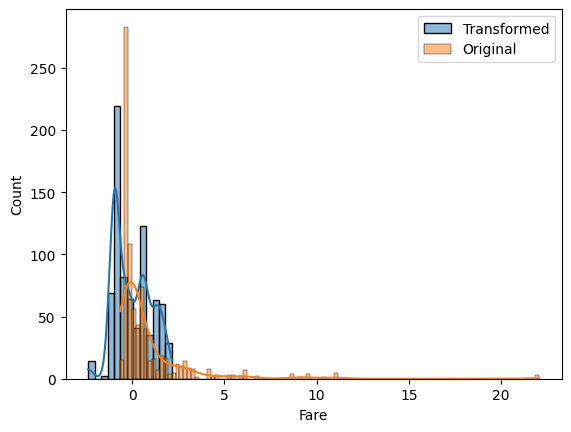

In [ ]:
sns.histplot(X_train_transoformed,kde=True,label='Transformed')
sns.histplot(X_train['Fare'],kde=True,label='Original')
plt.legend()

### 13. Comparing Distributions: Original vs. Transformed 'Fare'

These histograms visually compare the distribution of 'Fare' before and after the `PowerTransformer` is applied. The 'Original' distribution is highly skewed, while the 'Transformed' distribution appears much more symmetrical and closer to a normal distribution, as intended by the power transformation.

In [ ]:
pd.DataFrame(X_train_transoformed).skew()

,0
0,0.256694


### 14. Skewness After Power Transformation

After applying the `PowerTransformer`, we recalculate the skewness of the 'Fare' feature. The value is now much closer to zero (0.25), indicating that the transformation has successfully reduced the skewness and made the distribution more symmetrical, closer to a normal distribution.

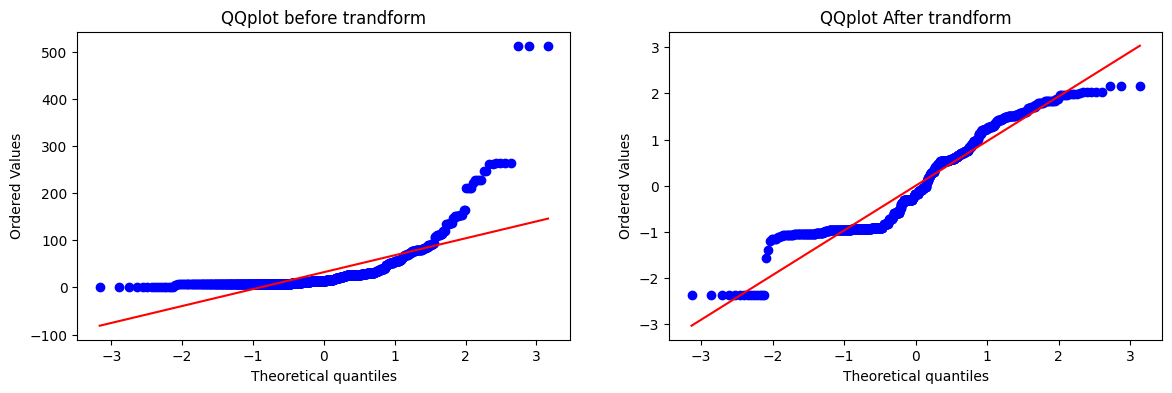

In [ ]:

plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(df['Fare'],dist='norm',plot=plt)
plt.title('QQplot before trandform')

plt.subplot(122)
stats.probplot(X_train_transoformed.flatten(),dist='norm',plot=plt)
plt.title('QQplot After trandform')
plt.show()


### 15. QQ Plots: Before and After Transformation

A Quantile-Quantile (QQ) plot is a graphical method for comparing two probability distributions by plotting their quantiles against each other. Here, we compare the quantiles of 'Fare' against the quantiles of a normal distribution.

*   **Before Transformation:** The QQ plot shows significant deviation from the red line, especially at the tails, indicating that 'Fare' is not normally distributed.
*   **After Transformation:** The QQ plot for the transformed 'Fare' shows that the points align much more closely with the red line, suggesting that the power transformation has brought the distribution closer to normality.

In [ ]:
def  transformations(transform_func):
  # Create a local copy of the DataFrame to avoid modifying the global 'df'
  # and select 'Age' and 'Fare' as features.
  X = df.iloc[:,1:3].fillna(df['Age'].mean()) # Fill missing 'Age' values with the mean
  Y = df.iloc[:,0] # 'Survived' is the target variable

  # Define a wrapper function to handle the input/output shape for FunctionTransformer
  # scipy.stats.boxcox and yeojohnson expect 1D arrays and return 1D arrays.
  # FunctionTransformer within ColumnTransformer expects 2D input and 2D output.
  def transformer_wrapper(X_col):
    # X_col will be a 2D array (n_samples, 1) from ColumnTransformer
    # Convert to NumPy array and then flatten it to 1D for scipy.stats functions
    # The '_ ' is used to discard the lambda parameter returned by boxcox/yeojohnson if not needed.
    transformed_data, _ = transform_func(X_col.to_numpy().flatten())
    # Reshape the 1D output back to 2D for ColumnTransformer
    return transformed_data.reshape(-1, 1)

  # Create a ColumnTransformer to apply the specified 'transform_func' function to the 'Fare' column.
  # 'remainder='passthrough'' ensures that other columns (like 'Age') are kept as they are.
  # We use the transformer_wrapper to adapt the scipy.stats functions.
  trf = ColumnTransformer([('log',FunctionTransformer(transformer_wrapper),['Fare'])],remainder='passthrough')
  X_trans = trf.fit_transform(X) # Apply the transformation to the features

  # Initialize and train a Logistic Regression model
  clf = LogisticRegression(solver='liblinear') # Using 'liblinear' solver for small datasets and L1/L2 regularization
  # Evaluate the model's accuracy using 10-fold cross-validation
  print('Accuracy',np.mean(cross_val_score(clf,X_trans,Y,scoring='accuracy',cv=10)))

  # Plot QQ plots to visualize the distribution of 'Fare' before and after transformation
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  stats.probplot(X['Fare'],dist='norm',plot=plt) # QQ plot for original 'Fare'
  plt.title('Before Transformation')

  plt.subplot(122)
  stats.probplot(X_trans[:,0],dist='norm',plot=plt) # QQ plot for transformed 'Fare' (first column)
  plt.title('After Transformation')

  plt.show()

Accuracy 0.6622596754057428


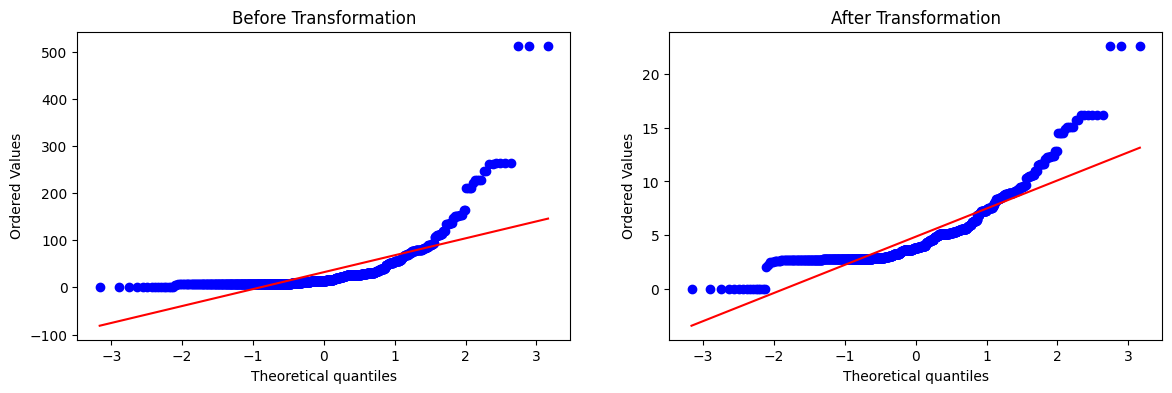

In [ ]:
transformations(np.sqrt)

### 16. Box-Cox Transformation

The Box-Cox transformation is a family of power transformations designed to transform non-normal variables into a normal shape.

**Important Constraint:** It is only applicable to **strictly positive data**. If your dataset contains zeros or negative numbers, you must either use the Yeo-Johnson transformation instead or shift your data by adding a constant (e.g., `x + 1`).

In the code below, we add a tiny offset (`0.000001`) to the 'Fare' column to satisfy this requirement.

Accuracy 0.6645443196004994


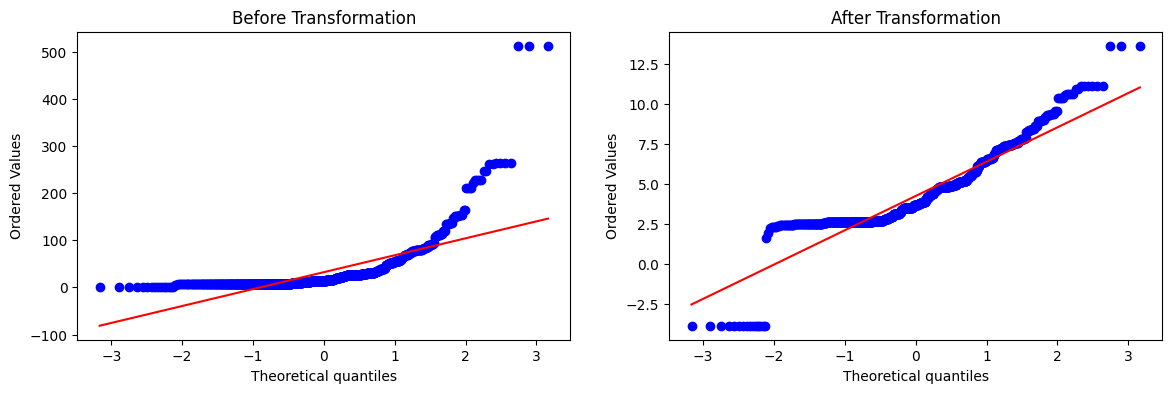

In [ ]:
# Box-Cox requires strictly positive data (> 0).
# We add a small constant (offset) to handle 0 or negative values in 'Fare'.
transformations(lambda x: stats.boxcox(x - x.min() + 0.0001))

### 17. Yeo-Johnson Transformation

Similar to Box-Cox, the Yeo-Johnson transformation is another power transformation technique used to normalize data. The key advantage of Yeo-Johnson over Box-Cox is that it can handle both positive and negative values, and even zero. The transformation is defined as:

*   For $y \ge 0$: $y(\lambda) = ((y+1)^\lambda - 1) / \lambda$ if $\lambda \ne 0$
*   For $y \ge 0$: $y(\lambda) = \log(y+1)$ if $\lambda = 0$
*   For $y < 0$: $y(\lambda) = -((1-y)^{2-\lambda} - 1) / (2-\lambda)$ if $\lambda \ne 2$
*   For $y < 0$: $y(\lambda) = -\log(1-y)$ if $\lambda = 2$

`stats.yeojohnson` also finds the optimal $\lambda$ parameter. Let's apply it to our 'Fare' data.

Accuracy 0.6712484394506867


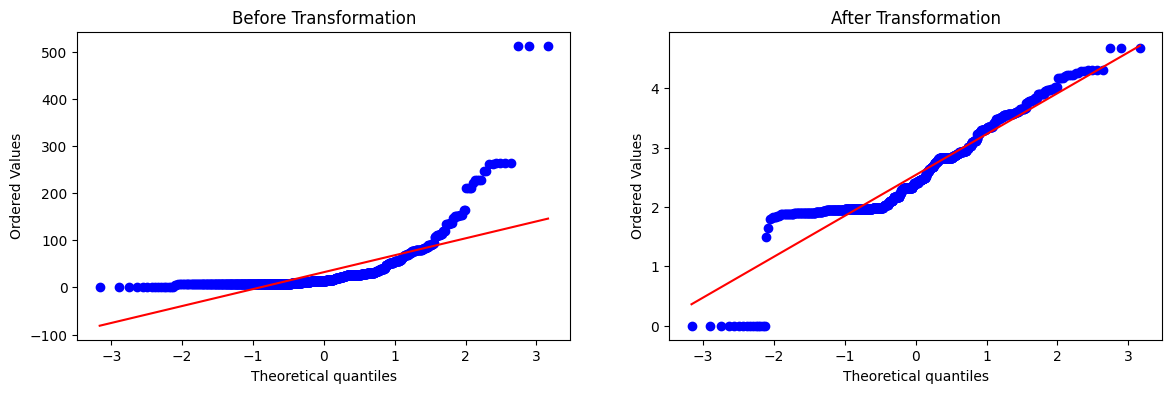

In [ ]:
transformations(stats.yeojohnson)

### Summary of Transformations

We have explored several transformations:

1.  **Square Root Transformation (`np.sqrt`):** A simple power transformation ($y^{0.5}$) effective for moderately right-skewed data. It achieved an accuracy of approximately **0.662**.
2.  **Box-Cox Transformation (`stats.boxcox`):** An adaptive power transformation that finds the optimal $\lambda$ for positively-valued data. It typically yields better normalization than fixed power transformations. The accuracy achieved with Box-Cox transformation is displayed in the output of the cell above.
3.  **Yeo-Johnson Transformation (`stats.yeojohnson`):** A more flexible adaptive power transformation that can handle zero and negative values, making it suitable for a wider range of data distributions. The accuracy achieved with Yeo-Johnson transformation is displayed in the output of the cell above.

Each transformation aims to make the feature distribution more Gaussian-like, which can often improve the performance of models that assume normally distributed inputs, such as Logistic Regression. The choice of transformation depends on the data's characteristics (e.g., presence of zeros or negative values, degree of skewness) and its impact on the chosen model's performance.

##MISSING VALUES Imputation

There are various methods to impute missing values from the dataset.

Three main types:

**1. Complete Case Analysis(CCA)**:

Discarding complete rows where any of the values are missing.

Important Considerations:
  1. Missing values should only contribute to less than 5% of the total data
  2. Missing values should be completely random

  


**2. Univariate imputation** :

When you use the same column to impute the missing value.


(A) Numerical Data:


*   Mean/median
*   Random impute
*   End of Distribution

(A) Categorical Data:


*   Mode impute
*   New Category (missing)



**3. Multivariate imputation** :
When you sue multiple columns to impute a specific missing value.


*   KNN imputer
*   Iterative imputer



**Important Considerations When imputing a missing value:**


1.   The distribution of the data must stay same before and after the imputation(specifically important for models like Linear regression and logistic Regression)
2.   There should not be a major difference in variance after imputation
3.   There should not be a mojor difference in corr/covariance before and after imputation.





##Complete Case Analysis(CCA)

Complete removal of missing values from the dataset.

We perform CCA on DataScience Jobs Dataset:

In [29]:
jobs = pd.read_csv('/content/data_science_job.csv')
jobs.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [30]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [31]:
jobs.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,479
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


In [32]:
# Find the percentage of missing values in each of the column
round(jobs.isnull().mean() * 100,2)


,0
enrollee_id,0.00
city,0.00
city_development_index,2.50
gender,23.53
relevent_experience,0.00
enrolled_university,2.01
education_level,2.40
major_discipline,14.68
experience,0.34
company_size,30.99


In [33]:
# Got the names of the columns for which the missing values are less than 5 %

cca_columns = [var for var in jobs.columns if (jobs[var].isnull().mean() < 0.05 and jobs[var].isnull().mean() > 0 )]
cca_columns

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

Check the category ratio in each columns: 
enrolled_university Before imputation percentage of observations per category, original data: enrolled_university
no_enrollment       0.721213
Full time course    0.196106
Part time course    0.062533
Name: count, dtype: float64


 enrolled_university Before imputation percentage of observations per category, original data: enrolled_university
no_enrollment       0.736043
Full time course    0.200139
Part time course    0.063818
Name: count, dtype: float64
Check the category ratio in each columns: 
education_level Before imputation percentage of observations per category, original data: education_level
Graduate          0.605387
Masters           0.227633
High School       0.105282
Phd               0.021610
Primary School    0.016077
Name: count, dtype: float64


 education_level Before imputation percentage of observations per category, original data: education_level
Graduate          0.620280
Masters           0.233234
High School       0.1

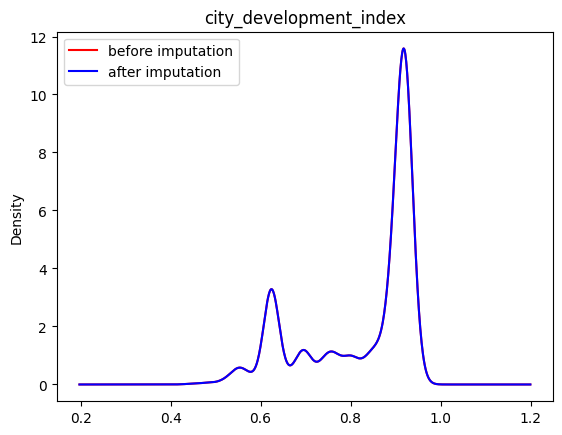

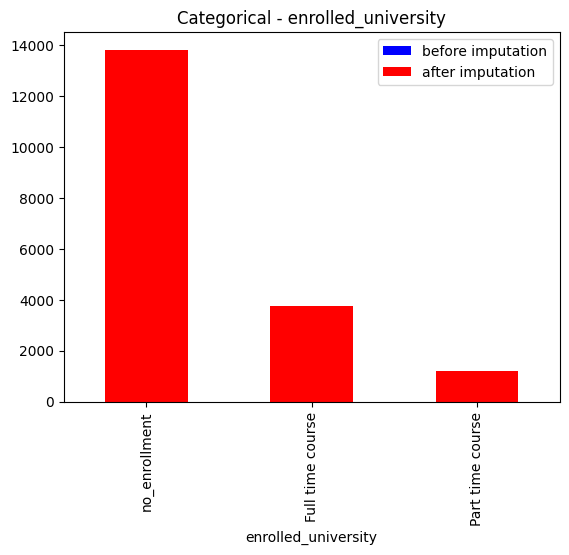

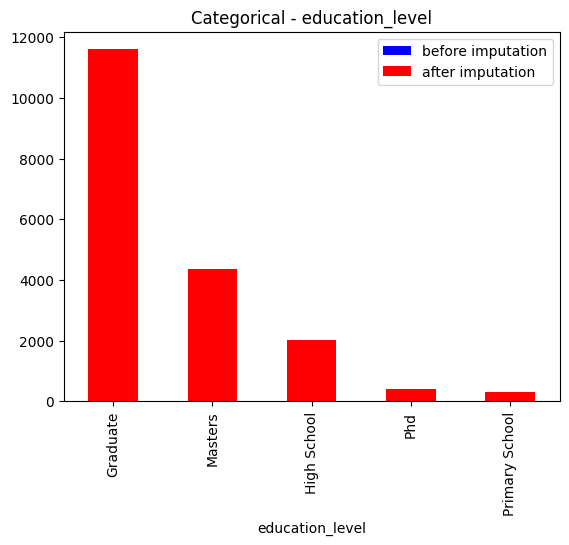

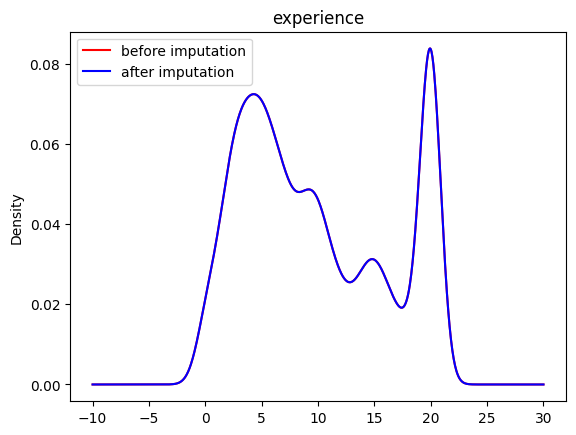

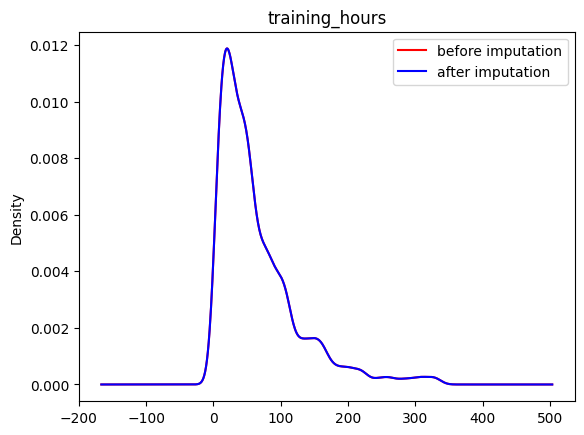

In [34]:
## Showing the complete deails before and after imputations
## We plot kde plot to compare the distributions of each column before and after imputations
## We compare the variances before and after imputation(Numerical)
## We compare correlation and covariance with other columns in the dataset(Numerical)
## We also make sure that percentage of observations per category before and after imputation remian almost similar

for col_name in cca_columns:
  #Distributions
  if jobs[col_name].dtype != 'O':
    plt.figure()
    plt.title(col_name)
    jobs[col_name].plot.density(color='red',label='before imputation')
    jobs[col_name].dropna().plot.density(color='blue',label='after imputation')
    plt.legend()
  else:
    plt.figure()
    plt.title('Categorical - ' + col_name)
    jobs[col_name].value_counts().plot(kind='bar',label='before imputation',color='blue')
    jobs[col_name].value_counts().dropna().plot(kind='bar',label='after imputation',color='red')
    plt.legend()

    print('Check the category ratio in each columns: ')
    # percentage of observations per category, original data
    print(f'{col_name} Before imputation percentage of observations per category, original data: {jobs[col_name].value_counts() / len(jobs)}')

    print('\n')
    # percentage of observations per category, cca data
    print(f' {col_name} Before imputation percentage of observations per category, original data: {jobs[col_name].dropna().value_counts() / len(jobs[col_name].dropna())}')



##Univariate Imputation # 1
Mean/Median:
It's simply replacing the missing values with mean/median of the column

Advantages:
Simple

Disadvantages: New Outliers, changed distribution

The considerations remain same:
1.   The distribution of the data must stay same before and after the imputation(specifically important for models like Linear regression and logistic Regression)
2.   There should not be a major difference in variance after imputation
3.   There should not be a mojor difference in corr/covariance before and after imputation.


In [35]:
# Using Pandas on titanic_dataset

titanic = pd.read_csv('/content/Titanic-Dataset.csv',usecols=['Age','Fare','Survived'])
titanic.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [36]:
titanic.isnull().sum()
round(titanic.isnull().mean()*100,2)
#We can see that the perecentage of missing values in the age column is >5% so we cannot apply CCA/mean/median imputation
#But we still apply mean/median imputation to see what happens

,0
Survived,0.00
Age,19.87
Fare,0.00


<Axes: ylabel='Density'>

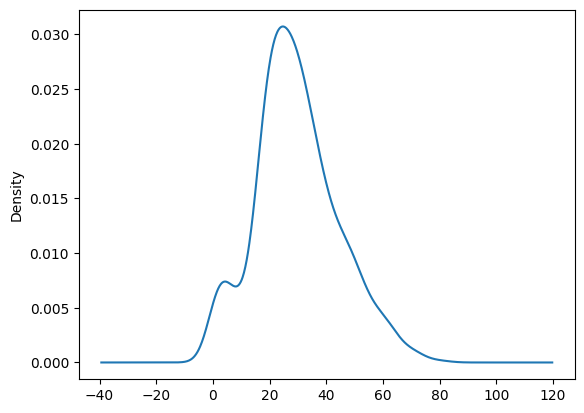

In [37]:
#Let's see distribution Age
titanic['Age'].plot(kind='kde')
#This is almost normal so it should not matter which impute (Mean/median) we apply
# But generally for skewed data we apply median imputation

In [38]:
#Imputation
mean_impute = titanic['Age'].fillna(titanic['Age'].mean())
median_impute = titanic['Age'].fillna(titanic['Age'].median())
mean_impute

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


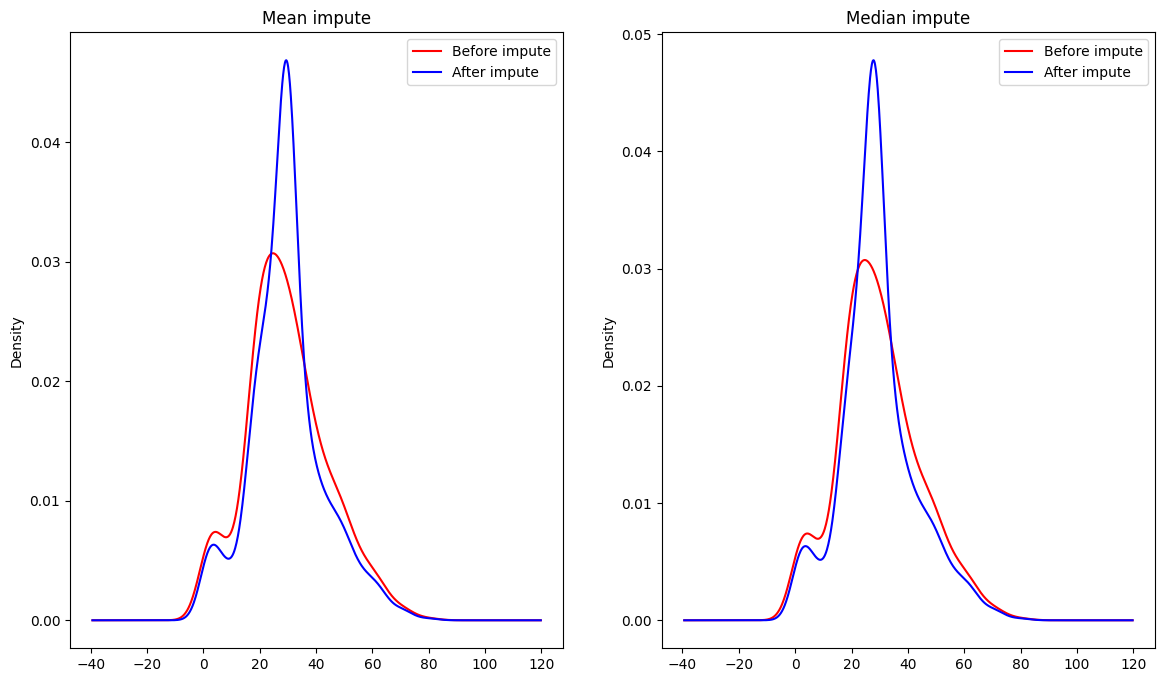

In [39]:
# Now lets compare distributions before and after imputatation
# Mean_impute
plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
plt.title('Mean impute')
titanic['Age'].plot(kind='kde',label= 'Before impute',color='red')
mean_impute.plot(kind='kde',label='After impute',color='blue')
plt.legend()

# Median_impute
plt.subplot(1,2,2)
plt.title('Median impute')
titanic['Age'].plot(kind='kde',label= 'Before impute',color='red')
median_impute.plot(kind='kde',label='After impute',color='blue')
plt.legend()

In [40]:
# Variances Analysis before and after impute
print(f'Mean_Analysis')
print(f'Variance Before Impute = {titanic['Age'].var()} ')
print(f'Variance After Impute = {mean_impute.var()} ')

print('\n')


print(f'Median_Analysis')
print(f'Variance Before Impute = {titanic['Age'].var()} ')
print(f'Variance After Impute = {median_impute.var()} ')

#We can see that there is huge difference between variances as well so mean/median imputation is not the best choice in this case

Mean_Analysis
Variance Before Impute = 211.0191247463081 
Variance After Impute = 169.05239993721085 


Median_Analysis
Variance Before Impute = 211.0191247463081 
Variance After Impute = 169.51249827942328 


In [41]:
# Now lets see covariance

titanic['mean_impute'] = mean_impute
titanic['median_impute'] = median_impute
titanic.cov()
# We can see that the covariance also changed a huge time

,Survived,Age,Fare,mean_impute,median_impute
Survived,0.236772,-0.551296,6.221787,-0.441656,-0.411226
Age,-0.551296,211.019125,73.849030,211.019125,211.019125
Fare,6.221787,73.849030,2469.436846,59.162200,62.556767
mean_impute,-0.441656,211.019125,59.162200,169.052400,169.052400
median_impute,-0.411226,211.019125,62.556767,169.052400,169.512498


In [42]:
# Now lets see correlation
titanic.corr()
#correlation also changed widely

,Survived,Age,Fare,mean_impute,median_impute
Survived,1.000000,-0.077221,0.257307,-0.069809,-0.064910
Age,-0.077221,1.000000,0.096067,1.000000,1.000000
Fare,0.257307,0.096067,1.000000,0.091566,0.096688
mean_impute,-0.069809,1.000000,0.091566,1.000000,0.998642
median_impute,-0.064910,1.000000,0.096688,0.998642,1.000000


In [43]:
## Using scikit learn on titanic toy data set
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

toy_titanic = pd.read_csv('/content/titanic_toy.csv')
X = toy_titanic.drop(columns=['Survived'])
Y = toy_titanic['Survived']

## Train/Test Split
X_train,X_test, Y_train,Y_test = train_test_split(X,Y,test_size = 0.1,random_state=42)

## Create imputer objects and define their strategy
sk_mean_imputer = SimpleImputer(strategy='mean')
sk_median_imputer = SimpleImputer(strategy='median')

## Create a column transformer to apply the imputations

imputations = ColumnTransformer([
    ('impute1',SimpleImputer(strategy='mean'),['Age']),
    ('impute2',SimpleImputer(strategy='median'),['Fare'])

]
)

## Fit on the X_train (ONLY!!)
imputations.fit(X_train)

## See the details of the Transformations
imputations.named_transformers_['impute1'].statistics_
imputations.named_transformers_['impute2'].statistics_

## Apply transformations on both Train and test
X_train_transformed = pd.DataFrame(imputations.transform(X_train))
X_test_transformed = pd.DataFrame(imputations.transform(X_test))

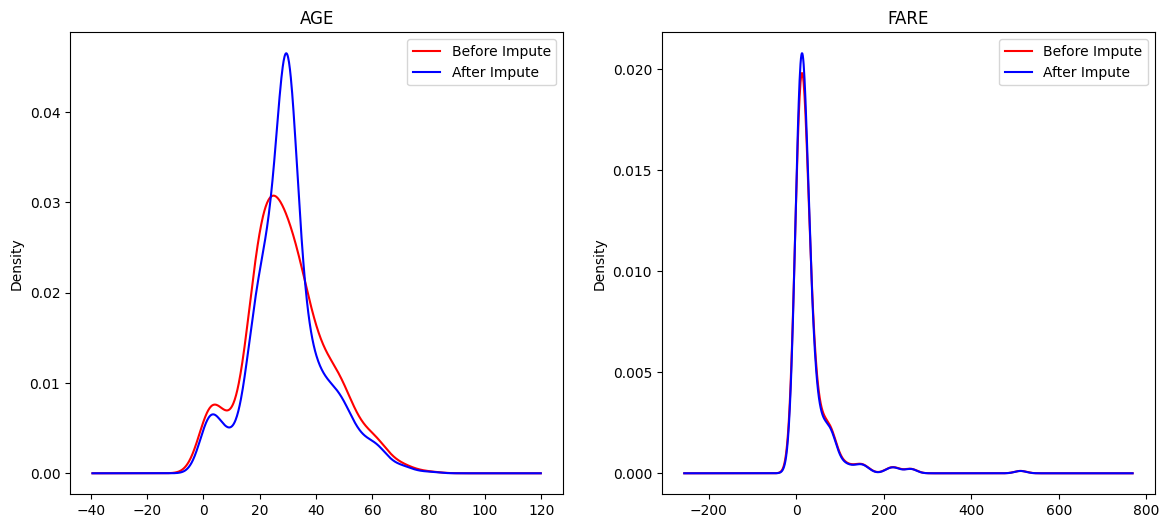

In [44]:
## Now lets see the comparision before and after imputations
#1.Distribution
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title('AGE')
X_train['Age'].plot(kind='kde',label='Before Impute',color='red')
X_train_transformed[0].plot(kind='kde',label='After Impute',color='blue')
plt.legend()

plt.subplot(1,2,2)
plt.title('FARE')
X_train['Fare'].plot(kind='kde',label='Before Impute',color='red')
X_train_transformed[1].plot(kind='kde',label='After Impute',color='blue')
plt.legend()


In [45]:
##2. Now Lets see Variances

print('Variance Analysis before and after imputations')
print('AGE')
print('\n')
print(f'X_train variance before imputation {X_train['Age'].var():.2f}')
print(f'X_train variance after imputation {X_train_transformed[0].var():.2f}')
print('\n')
print('FARE')
print('\n')
print(f'X_train variance before imputation {X_train['Fare'].var():.2f}')
print(f'X_train variance before imputation {X_train_transformed[1].var():.2f}')
## We can see that for the Age column there is noticeable difference but for the Fare column the difference is not huge so we can conclude that for Fare the median imputation works just fine.

Variance Analysis before and after imputations
AGE


X_train variance before imputation 213.44
X_train variance after imputation 170.22


FARE


X_train variance before imputation 2586.22
X_train variance before imputation 2468.94


## Univariate imputation #2
Random imputation: Just replace the missing values by a random value of your choice.

In [46]:
# Using pandas

#1. See the percentage of missing values
toy_titanic.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [47]:
#Use pandas fillna function to fill the missing values with a arbitary value
rand_fill_age = toy_titanic['Age'].fillna(999)
rand_fill_fare = toy_titanic['Fare'].fillna(-1)

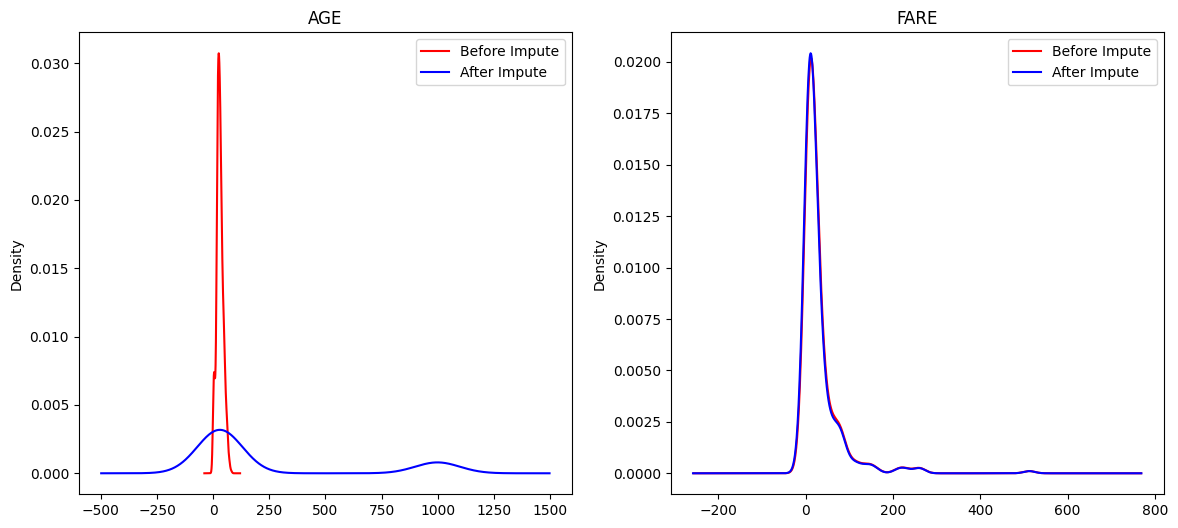

In [48]:
## Now lets see the comparision before and after imputations
#1.Distribution
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title('AGE')
toy_titanic['Age'].plot(kind='kde',label='Before Impute',color='red')
rand_fill_age.plot(kind='kde',label='After Impute',color='blue')
plt.legend()

plt.subplot(1,2,2)
plt.title('FARE')
toy_titanic['Fare'].plot(kind='kde',label='Before Impute',color='red')
rand_fill_fare.plot(kind='kde',label='After Impute',color='blue')
plt.legend()



In [49]:
## Using sklearn

## Train/Test Split
X_train,X_test, Y_train,Y_test = train_test_split(X,Y,test_size = 0.1,random_state=42)

## Create a column transformer to apply the imputations

imputations = ColumnTransformer([
    ('impute1',SimpleImputer(strategy='constant',fill_value=999),['Age']),
    ('impute2',SimpleImputer(strategy='constant',fill_value=-1),['Fare'])

]
)

## Fit on the X_train (ONLY!!)
imputations.fit(X_train)

## See the details of the Transformations
imputations.named_transformers_['impute1'].statistics_
imputations.named_transformers_['impute2'].statistics_

## Apply transformations on both Train and test
X_train_transformed = pd.DataFrame(imputations.transform(X_train))
X_test_transformed = pd.DataFrame(imputations.transform(X_test))

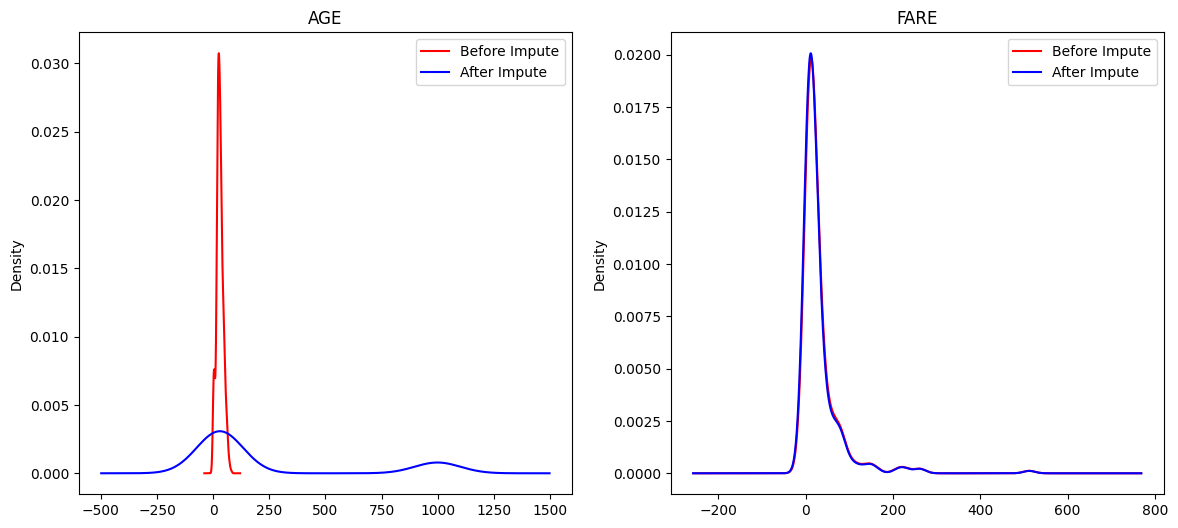

In [50]:
## Now lets see the comparision before and after imputations
#1.Distribution
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title('AGE')
X_train['Age'].plot(kind='kde',label='Before Impute',color='red')
X_train_transformed[0].plot(kind='kde',label='After Impute',color='blue')
plt.legend()

plt.subplot(1,2,2)
plt.title('FARE')
X_train['Fare'].plot(kind='kde',label='Before Impute',color='red')
X_train_transformed[1].plot(kind='kde',label='After Impute',color='blue')
plt.legend()

In [52]:
##2. Now Lets see Variances

print('Variance Analysis before and after imputations')
print('AGE')
print('\n')
print(f'X_train variance before imputation {X_train['Age'].var():.2f}')
print(f'X_train variance after imputation {X_train_transformed[0].var():.2f}')
print('\n')
print('FARE')
print('\n')
print(f'X_train variance before imputation {X_train['Fare'].var():.2f}')
print(f'X_train variance before imputation {X_train_transformed[1].var():.2f}')
## We can see that for the Age column there is noticeable difference but for the Fare column the difference is not huge so we can conclude that for Fare the median imputation works just fine.

Variance Analysis before and after imputations
AGE


X_train variance before imputation 213.44
X_train variance after imputation 151932.70


FARE


X_train variance before imputation 2586.22
X_train variance before imputation 2507.17


##Univariate Imputation # 3
End of Distribution: Missing values are replaced by end of distrbution values

1)Normal distribution (mean + 3 * std) OR (mean - 3 * std)

2)Skewed Data (q1 - 1.5 * IQR) OR (q3 + 1.5 * IQR)

Used when datta is not missing at random.

We use a single boundary /either upper or lower depending on what we expect our missing values could entail. For example, if we expect our missing values in the age column could relate to children with lower age group we replace it with a lower boundary i.e ( (mean - 3 * std)) OR (q1 - 1.5 * IQR)

In [53]:

# Load the toy_titanic dataset
toy_titanic = pd.read_csv('/content/titanic_toy.csv')
X = toy_titanic.drop(columns=['Survived'])
Y = toy_titanic['Survived']

# Train/Test Split
X_train,X_test, Y_train,Y_test = train_test_split(X,Y,test_size = 0.1,random_state=42)

# Calculate end-of-distribution values for Age and Fare
# For Age (approximately normal), use mean + 3*std
age_mean = X_train['Age'].mean()
age_std = X_train['Age'].std()
age_upper_boundary = age_mean + 3 * age_std

# For Fare (skewed), use Q3 + 1.5*IQR
fare_q1 = X_train['Fare'].quantile(0.25)
fare_q3 = X_train['Fare'].quantile(0.75)
fare_iqr = fare_q3 - fare_q1
fare_upper_boundary = fare_q3 + 1.5 * fare_iqr

print(f"Age upper boundary for imputation: {age_upper_boundary:.2f}")
print(f"Fare upper boundary for imputation: {fare_upper_boundary:.2f}")

Age upper boundary for imputation: 73.58
Fare upper boundary for imputation: 65.61


In [54]:
# Create imputer objects and define their strategy
# Using constant strategy with calculated end-of-distribution values
imputations_eod = ColumnTransformer([
    ('impute_age_eod', SimpleImputer(strategy='constant', fill_value=age_upper_boundary), ['Age']),
    ('impute_fare_eod', SimpleImputer(strategy='constant', fill_value=fare_upper_boundary), ['Fare'])
], remainder='passthrough') # Keep other columns as they are

# Fit on the X_train (ONLY!!)
imputations_eod.fit(X_train)

# Apply transformations on both Train and test
X_train_transformed_eod = pd.DataFrame(imputations_eod.transform(X_train))
X_test_transformed_eod = pd.DataFrame(imputations_eod.transform(X_test))

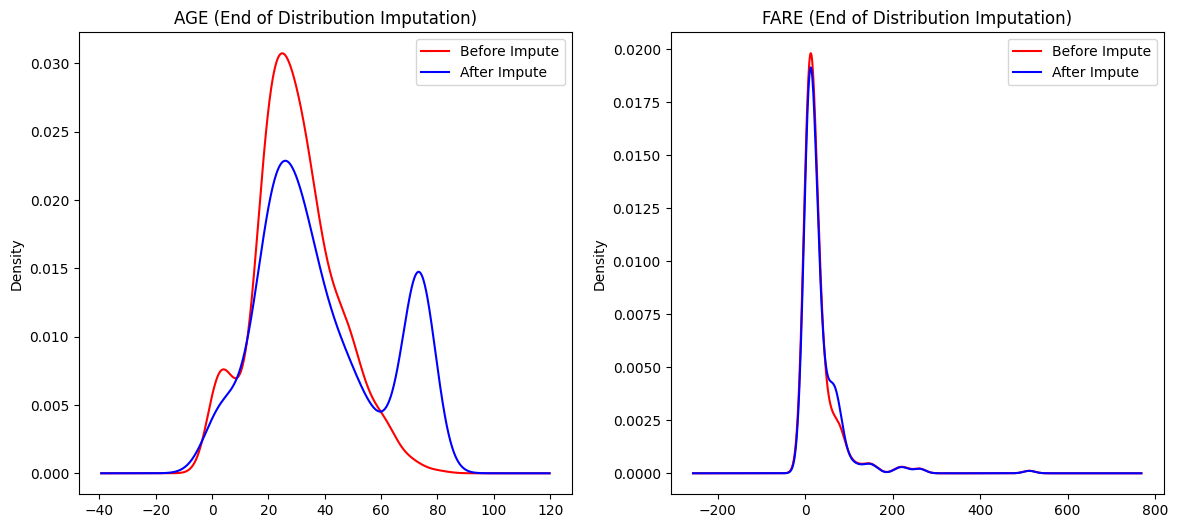


Variance Analysis before and after imputations (End of Distribution)
AGE
X_train variance before imputation 213.44
X_train variance after imputation 480.55

FARE
X_train variance before imputation 2586.22
X_train variance after imputation 2508.07


In [55]:
# Now let's see the comparison before and after imputations
# 1. Distribution
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title('AGE (End of Distribution Imputation)')
X_train['Age'].plot(kind='kde',label='Before Impute',color='red')
X_train_transformed_eod[0].plot(kind='kde',label='After Impute',color='blue')
plt.legend()

plt.subplot(1,2,2)
plt.title('FARE (End of Distribution Imputation)')
X_train['Fare'].plot(kind='kde',label='Before Impute',color='red')
X_train_transformed_eod[1].plot(kind='kde',label='After Impute',color='blue')
plt.legend()
plt.show()

# 2. Now Let's see Variances
print('\nVariance Analysis before and after imputations (End of Distribution)')
print('AGE')
print(f'X_train variance before imputation {X_train['Age'].var():.2f}')
print(f'X_train variance after imputation {X_train_transformed_eod[0].var():.2f}')
print('\nFARE')
print(f'X_train variance before imputation {X_train['Fare'].var():.2f}')
print(f'X_train variance after imputation {X_train_transformed_eod[1].var():.2f}')

##Univariate Imputation # 4
Random Sample Imputation: We simply impute the missing values with a random value in the same column.

The best thing about this imputation is that it keeps the distributuion of the column or feature exactly similar.

<Axes: ylabel='Density'>

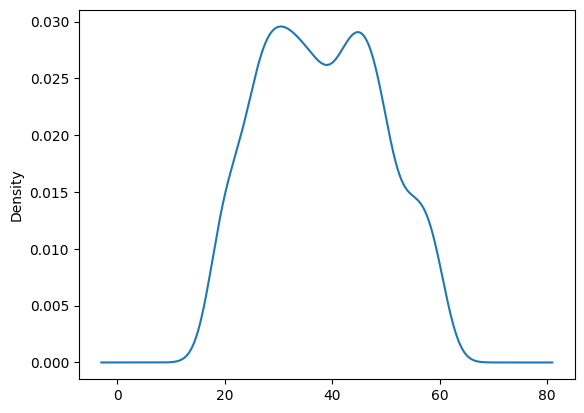

In [76]:
## Load the titanic data set
titanic = pd.read_csv('Titanic-Dataset.csv',usecols= ['Age','Fare','Survived'])

#lets see the distribution of Age
df['age'].plot(kind='kde')


In [77]:
## Drop the missing values from the Age column to and select random sample to impute the missing values
titanic.loc[titanic['Age'].isnull(),'Age'] =  titanic['Age'].dropna().sample(177).values

<Axes: ylabel='Density'>

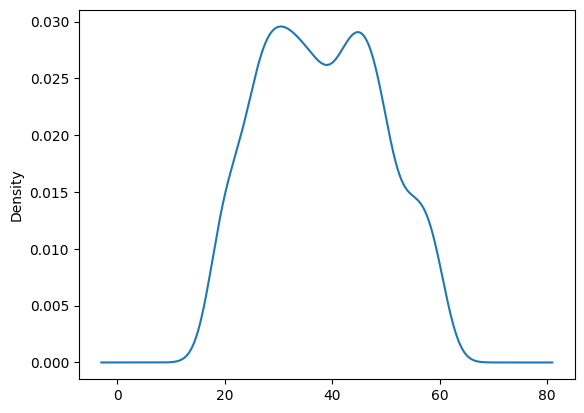

In [78]:
titanic['Age'].isnull().sum()
#Now lets see the distribution again
df['age'].plot(kind='kde')
## As we can see that is no difference in the distribution

## Missing Categorical Data
1. Fill by most frequent Value
2. Missing Category Imputation: Create a totally new categroy that indicates to a missing value (this also works with numerical data)

(This should be done generally when one of the category is dominant)

In [80]:
## Fill by most frequent Value
train = pd.read_csv('/content/train (1).csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
train.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [81]:
train.isnull().sum()

,0
FireplaceQu,690
GarageQual,81
SalePrice,0


<Axes: xlabel='FireplaceQu'>

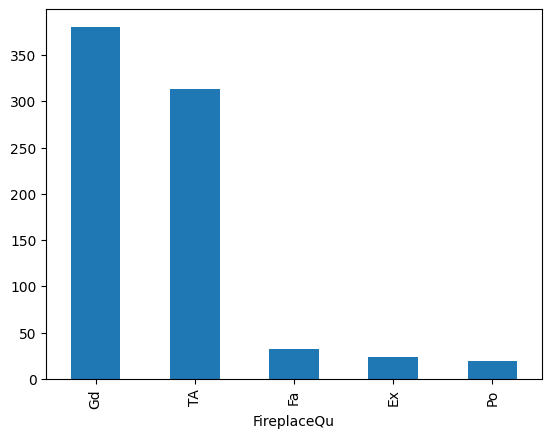

In [83]:
train['FireplaceQu'].value_counts().plot(kind='bar')

<Axes: xlabel='GarageQual'>

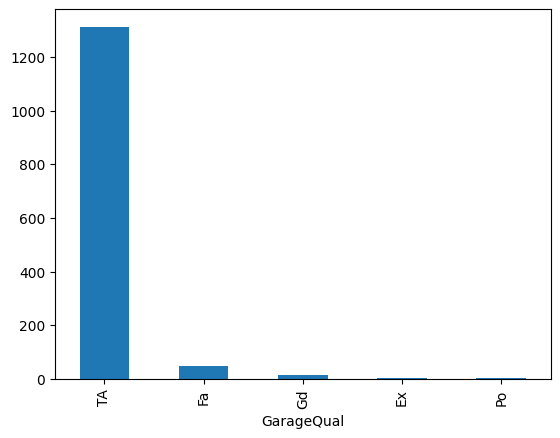

In [84]:
train['GarageQual'].value_counts().plot(kind='bar')

In [93]:
#Using Pandas
train['FireplaceQu'].fillna(train['FireplaceQu'].mode()[0],inplace=True)

train['GarageQual'].fillna(train['GarageQual'].mode()[0],inplace=True)

np.int64(0)

<Axes: xlabel='FireplaceQu'>

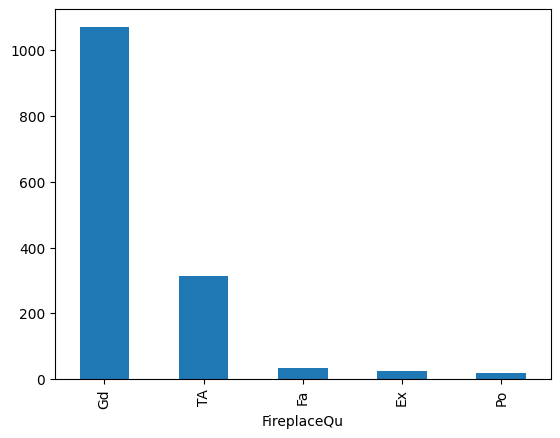

In [95]:
# Lets see distributions after applying
train['FireplaceQu'].value_counts().plot(kind='bar')


<Axes: xlabel='GarageQual'>

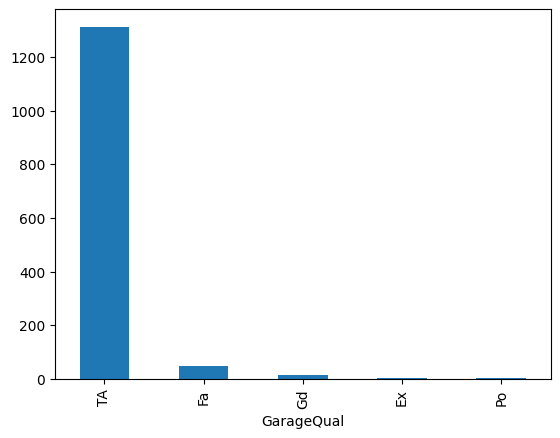

In [96]:
train['GarageQual'].value_counts().plot(kind='bar')

In [104]:
#Using Scikit Learn
saleprice = pd.read_csv('/content/train (1).csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

X = saleprice.drop(columns=['SalePrice'])
Y = saleprice['SalePrice']

#train/test split
X_train,X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.1,random_state=42)

## Create Imputer Transformer
imputer_trans = ColumnTransformer([
    ('imp1',SimpleImputer(strategy='most_frequent'),['GarageQual']),
    ('imp2',SimpleImputer(strategy='most_frequent'),['FireplaceQu']),
])

## fit and tranform
X_train = imputer_trans.fit_transform(X_train)
X_test = imputer_trans.fit_transform(X_test)

## See the statistics
imputer_trans
imputer_trans['imp1'].statistics_
imputer_trans['imp2'].statistics_


array(['Gd'], dtype=object)

## Missing Category Imputation
It involves creating a totally new cateogry to indiacte that a specific value was missing in the dataset.

In [106]:
saleprice = pd.read_csv('/content/train (1).csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
saleprice.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


Text(0, 0.5, 'Number of houses')

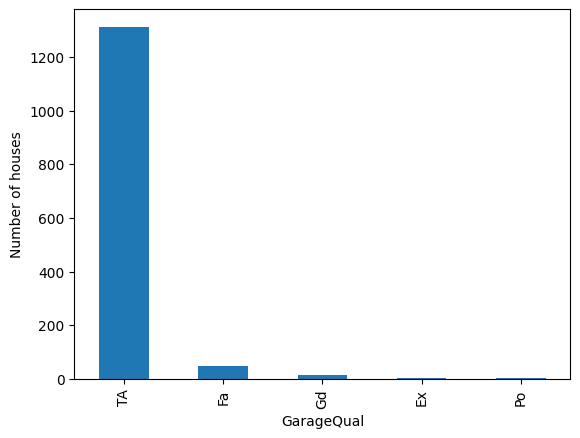

In [108]:
saleprice['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

/tmp/ipykernel_600/4192065845.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  saleprice['GarageQual'].fillna('Missing', inplace=True)


Text(0, 0.5, 'Number of houses')

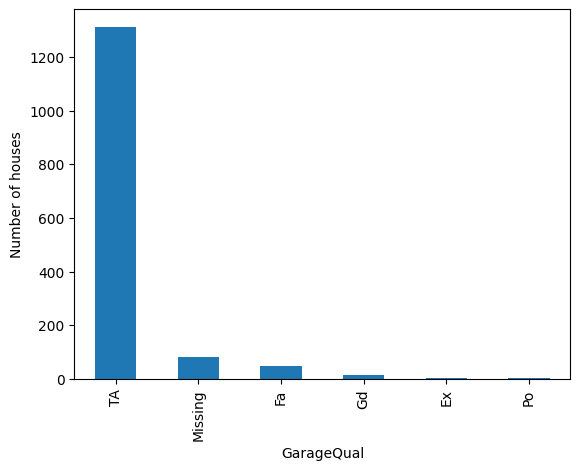

In [110]:
saleprice['GarageQual'].fillna('Missing', inplace=True)
saleprice['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

In [113]:
## Using Scikit Learn
X_train,X_test,y_train,y_test = train_test_split(saleprice.drop(columns=['SalePrice']),saleprice['SalePrice'],test_size=0.2)


In [114]:
# imputer class
imputer = SimpleImputer(strategy='constant',fill_value='Missing')

In [115]:
## fit and transform
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [116]:
# obeserve Statisitics
imputer.statistics_


array(['Missing', 'Missing'], dtype=object)

## Advanced Missing Value Filler (Multivariate)
1) KNN imputer:
The KNN Imputer (K-Nearest Neighbors Imputer) fills in missing data by identifying the k most similar rows (neighbors) in a dataset and averaging their values. It is a multivariate imputation method, meaning it looks at multiple features simultaneously to preserve relationships within the data, unlike simple methods that look at only one column (like mean or median imputation).


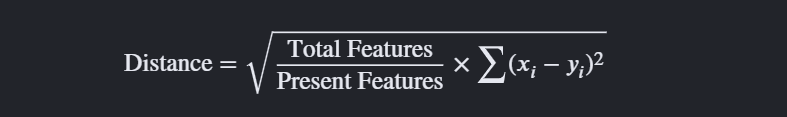



How it works, step by step:

1. Pick K — decide how many neighbors to compare (e.g., K=5).
For each row with a missing value (say, missing Age):

2. Look at that row's other columns (e.g., Fare, Pclass, SibSp) — the ones that aren't missing.
3. Find the K most similar rows — using distance (usually Euclidean) calculated only from the columns that are present. Rows with the closest overall values across those features are the "nearest neighbors."
4. Average the neighbors' values for the missing column — take those K neighbors' Age values and average them (can be weighted by distance, so closer neighbors count more).
5. Fill in the missing value with that computed average.
6. Repeat for every missing value in the dataset.

The parameter n_neighbors controls exactly how many similar rows (neighbors) the algorithm looks at to calculate the missing value.



1. Does the data need to be sorted?No, the data does not need to be sorted before using a KNN Imputer.The algorithm calculates the distance between rows mathematically using their coordinate values, completely ignoring the row order or index. Sorting your data ahead of time will not change the results, nor will it speed up the computation.

However, you must scale your data (using tools like MinMaxScaler or StandardScaler) before running the imputer. Because KNN relies on distance, features with larger numbers (like Salary: $80,000) will completely overpower features with smaller numbers (like Age: 30) unless they are normalized to the same scale.


For Numerical FeaturesWorks perfectly out of the box.The missing value is filled using the mean (average) of the neighbors.For Categorical Features (The Workaround)To make it work for categories, you must encode the text into numbers first

In [121]:
## Using Scikit Learn
from sklearn.impute import KNNImputer

titanic = pd.read_csv('/content/Titanic-Dataset.csv')



In [123]:
k_imputer = KNNImputer(n_neighbors = 5)
# Apply k_imputer to the numerical columns 'Age', 'Fare', 'Pclass'
# It's good practice to ensure these columns are indeed numerical before imputation
titanic[['Age', 'Fare', 'Pclass']] = k_imputer.fit_transform(titanic[['Age', 'Fare', 'Pclass']])

# Verify if missing values have been imputed
print("Missing values after KNN imputation:")
print(titanic[['Age', 'Fare', 'Pclass']].isnull().sum())

Missing values after KNN imputation:
Age       0
Fare      0
Pclass    0
dtype: int64


## Multivariate Imputations by Chained Equations
Unlike simple methods that fill a missing value just once, MICE is a sophisticated, iterative algorithm that guesses missing values multiple times by turning every column with missing data into a series of sub-machine learning problems.It is highly regarded because it excels at handling complex datasets containing a mix of numerical, categorical, and binary data.

Steps:
- Fill all NAN with mean/median
- Pick one column at a time, treat it as target (y)
- Use other columns as Input (X) (Note: "target" is crossed out before "Input")- Train a model to predict missing values
- Replace the picked column value with predicted
- Do this for all columns
- Do 1-6 step till diff bw imputed & predicted value is near to 0


In [125]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer  # must import this first
from sklearn.impute import IterativeImputer

# Load data
titanic = pd.read_csv('/content/Titanic-Dataset.csv')

# Pick simple numeric columns to work with
data = titanic[['Age', 'Fare', 'Pclass', 'SibSp']]

# Create the MICE imputer
imputer = IterativeImputer(max_iter=10, random_state=42)

# Fill in missing values
filled_data = imputer.fit_transform(data)

# Convert back to a DataFrame
filled_df = pd.DataFrame(filled_data, columns=data.columns)

# Put the fixed Age column back into titanic
titanic['Age'] = filled_df['Age']

# Check — should print 0
print(titanic['Age'].isnull().sum())

0


##OUTLIERS (DETECTION AND REMOVAL)
Outlier: A data point that is different from all other data points

In some cases, outlier do not need to be removed like anamoly detection but in algorithms like linear regression, logistic regression and Deep learning etc, outliers have high impact.

Two ways to deal with outliers:
1. Triming (Remove completely):
- Fast
- May reduce data size

2. Capping(limit the outliers): As outlier is always left or right skewed we implement a cap and say that anything above that cap has the capped value.


Techniques for ourtlier Removal:
1. Z-Score Treatment
2. IQR based filtering
3. Percentile
4. Wisorization




#Z_score Treatment:
Assumption : data is normally normally distributed

This implies that:

Anything above (mean + 3 * std) OR  below (mean - 3 * std) is an outlier



In [126]:
## Load dataset
df = pd.read_csv('/content/placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: title={'center': 'placement_exam_marks'}, ylabel='Density'>

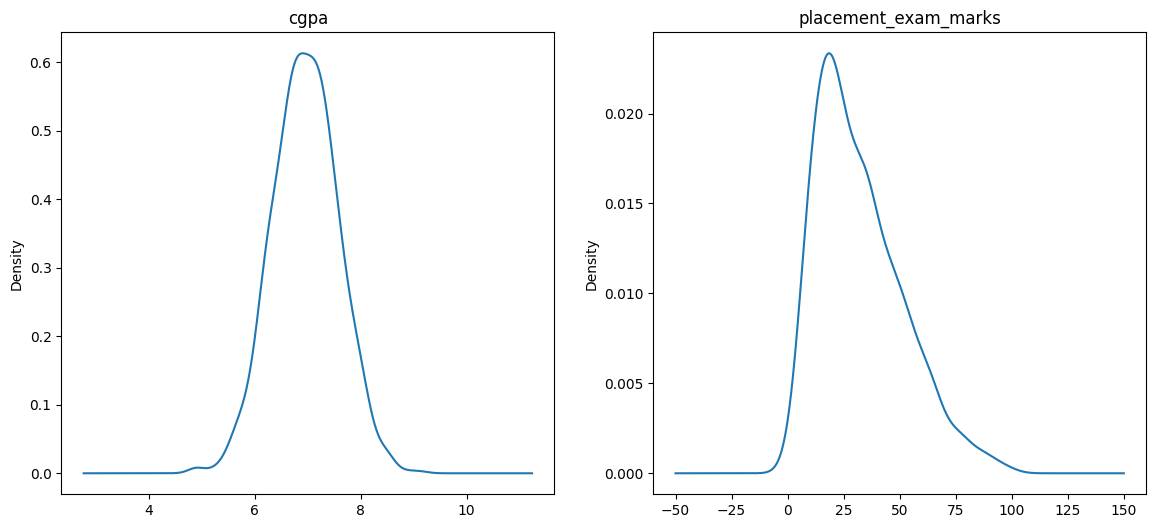

In [133]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title('cgpa')
df['cgpa'].plot(kind='kde')

plt.subplot(1,2,2)
plt.title('placement_exam_marks')
df['placement_exam_marks'].plot(kind='kde')


##Both appear normal so we can apply Z_score

In [139]:
##Trimming
## First see outliers
df[(df['cgpa'] > (df['cgpa'].mean() +  3 *(df['cgpa'].std()))) | (df['cgpa'] < (df['cgpa'].mean() -  3 *(df['cgpa'].std())))]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [147]:
## now create the new dataframe

new_df = df[
    (df['cgpa'] < (df['cgpa'].mean() +  3 *(df['cgpa'].std()))) &
    (df['cgpa'] > (df['cgpa'].mean() -  3 *(df['cgpa'].std())))
]

In [154]:
## Recheck for outliers in the new_df
# Calculate mean and std for the 'cgpa' column in new_df
mean_new_df_cgpa = new_df['cgpa'].mean()
std_new_df_cgpa = new_df['cgpa'].std()

# Define the outlier condition for new_df
new_df[
    (new_df['cgpa'] > (mean_new_df_cgpa + 3 * std_new_df_cgpa)) |
    (new_df['cgpa'] < (mean_new_df_cgpa - 3 * std_new_df_cgpa))
]



,cgpa,placement_exam_marks,placed


In [185]:
#Capping
upperlimit = df['cgpa'].mean() +  3 *(df['cgpa'].std())
lowerlimit =  df['cgpa'].mean() -  3 *(df['cgpa'].std())

cap_df = np.where(df['cgpa'] > upperlimit,
                  upperlimit,
                  np.where(
                      df['cgpa'] < lowerlimit,
                      lowerlimit,
                      df['cgpa']))


In [182]:
# Recheck for outliers in the capped data (cap_df)

mean_cap_cgpa = cap_df.mean()
std_cap_cgpa = cap_df.std()

outliers_in_cap_df = cap_df[
    (cap_df > (mean_cap_cgpa + 3 * std_cap_cgpa)) |
    (cap_df < (mean_cap_cgpa - 3 * std_cap_cgpa))
]

outliers_in_cap_df ## replaced with the upper bound

array([5.12803524, 5.12803524, 5.12803524])

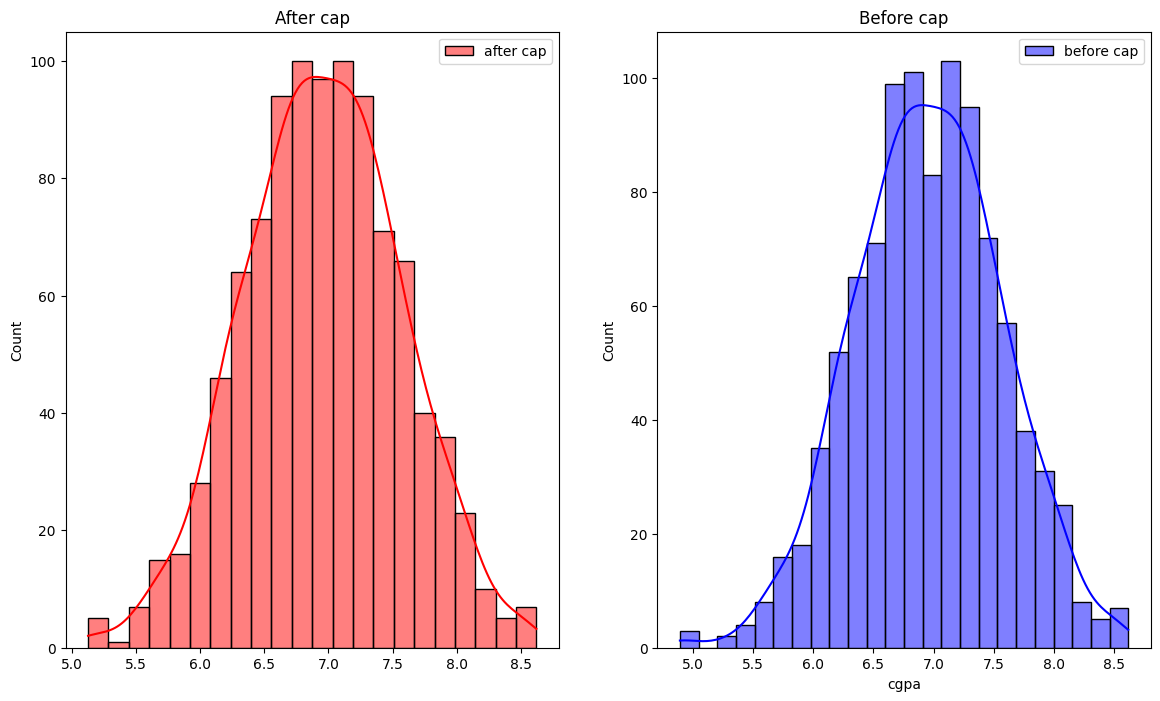

In [212]:
## See the distributions again
plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
sns.histplot(cap_df,color='red',kde=True, label='after cap')
plt.title('After cap')
plt.legend()
plt.subplot(1,2,2)
sns.histplot(data=df,x = 'cgpa', kde=True, color='blue', label='before cap')
plt.title('Before cap')
plt.legend()


## IQR Based Filtering
Used primarily for **skewed distributions** where Z-score is not appropriate.

**Steps:**
1. Calculate Q1 (25th percentile) and Q3 (75th percentile).
2. Calculate IQR = Q3 - Q1.
3. Define boundaries:
   - Upper Bound = Q3 + 1.5 * IQR
   - Lower Bound = Q1 - 1.5 * IQR
4. Anything outside [Lower Bound, Upper Bound] is an outlier.

In [201]:
# Calculate boundaries for 'placement_exam_marks'
q1 = df['placement_exam_marks'].quantile(0.25)
q3 = df['placement_exam_marks'].quantile(0.75)
iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr

print("Upper Limit:", upper_limit)
print("Lower Limit:", lower_limit)

# Find Outliers
outliers_iqr = df[(df['placement_exam_marks'] > upper_limit) | (df['placement_exam_marks'] < lower_limit)]
print(f"Number of outliers detected: {len(outliers_iqr)}")
display(outliers_iqr.head())

Upper Limit: 84.5
Lower Limit: -23.5
Number of outliers detected: 15


,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0


Text(0.5, 1.0, 'After Trimming (Distribution)')

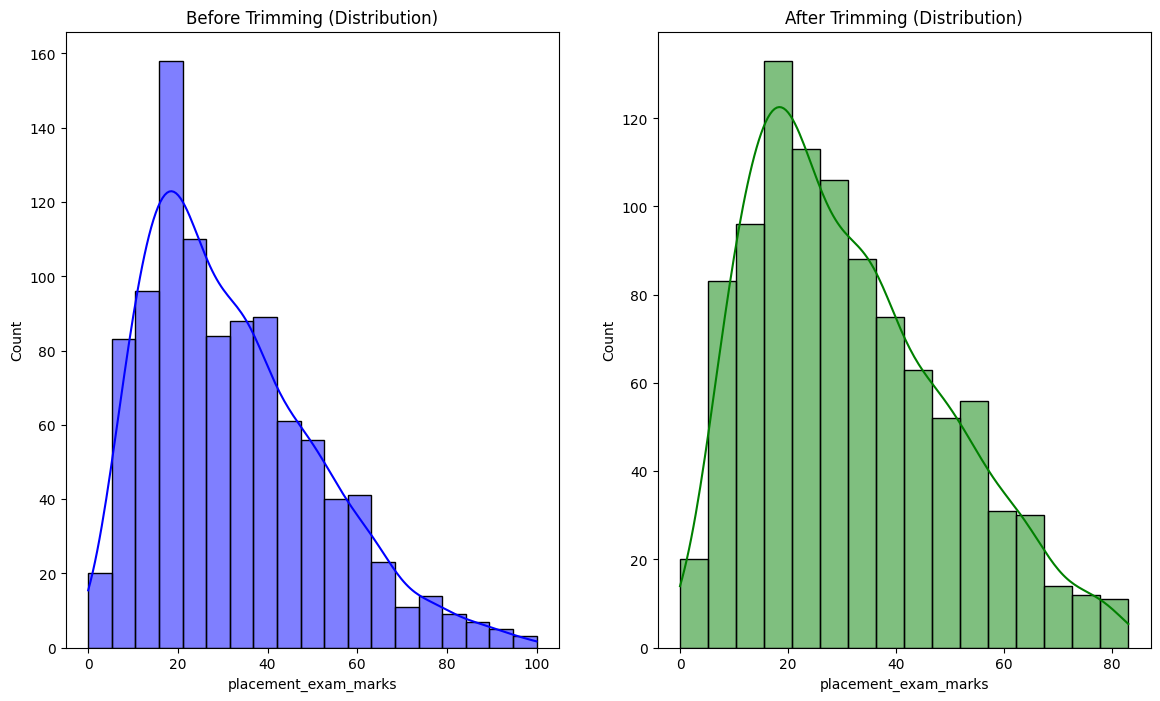

In [204]:
# Trimming outliers
new_df_iqr = df[(df['placement_exam_marks'] <= upper_limit) & (df['placement_exam_marks'] >= lower_limit)]

# Compare Distributions (KDE)
plt.figure(figsize=(14,8))

plt.subplot(1,2,1)
sns.histplot(df['placement_exam_marks'], kde=True, color='blue')
plt.title('Before Trimming (Distribution)')


plt.subplot(1,2,2)
sns.histplot(new_df_iqr['placement_exam_marks'], kde=True, color='green')
plt.title('After Trimming (Distribution)')



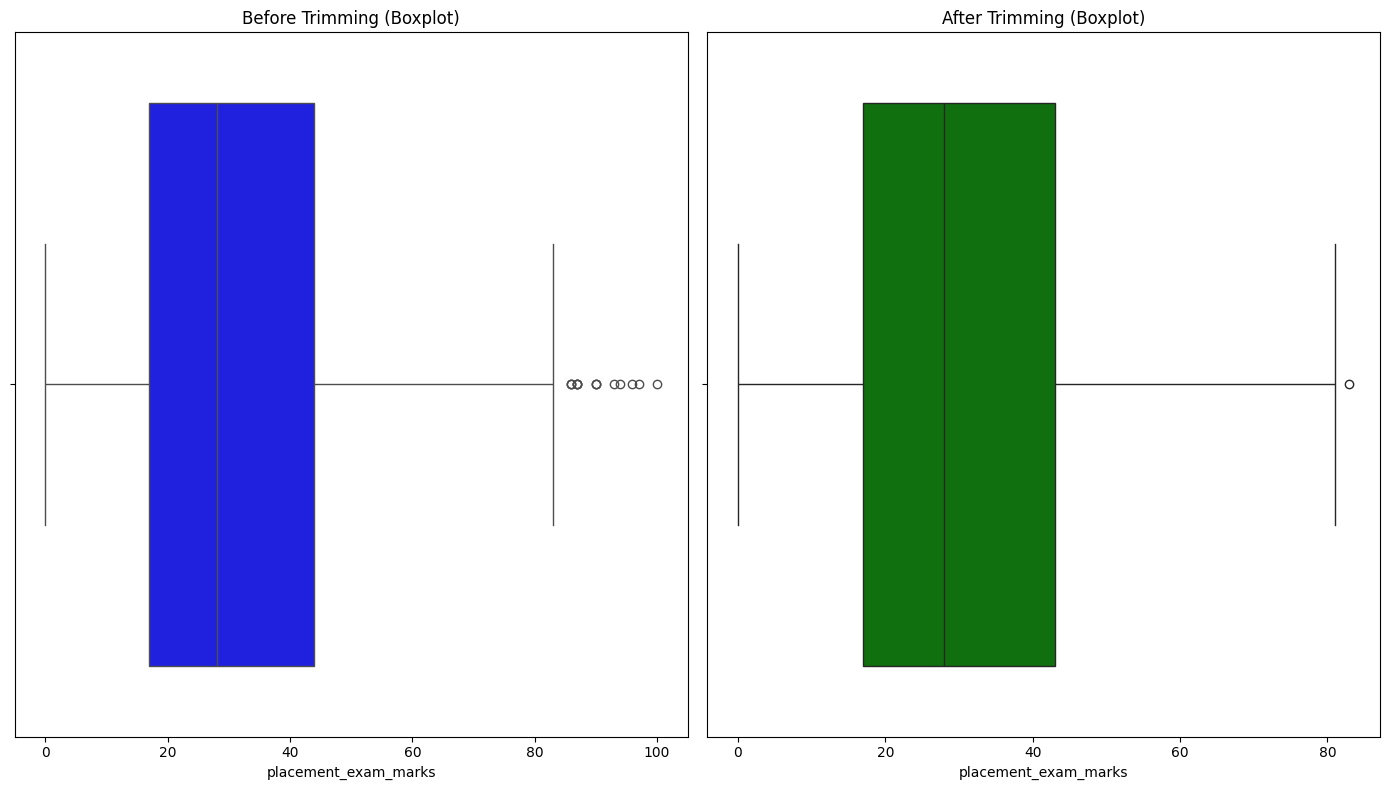

In [206]:
#BOX Plots

plt.figure(figsize=(14,8))


plt.subplot(1,2,1)
sns.boxplot(x=df['placement_exam_marks'], color='blue')
plt.title('Before Trimming (Boxplot)')

plt.subplot(1,2,2)
sns.boxplot(x=new_df_iqr['placement_exam_marks'], color='green')
plt.title('After Trimming (Boxplot)')

plt.tight_layout()

In [210]:
# Perform Capping (Winsorization)
df_cap_iqr = df.copy()

df_cap_iqr['placement_exam_marks'] = np.where(
    df_cap_iqr['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        df_cap_iqr['placement_exam_marks'] < lower_limit,
        lower_limit,
        df_cap_iqr['placement_exam_marks']
    )
)



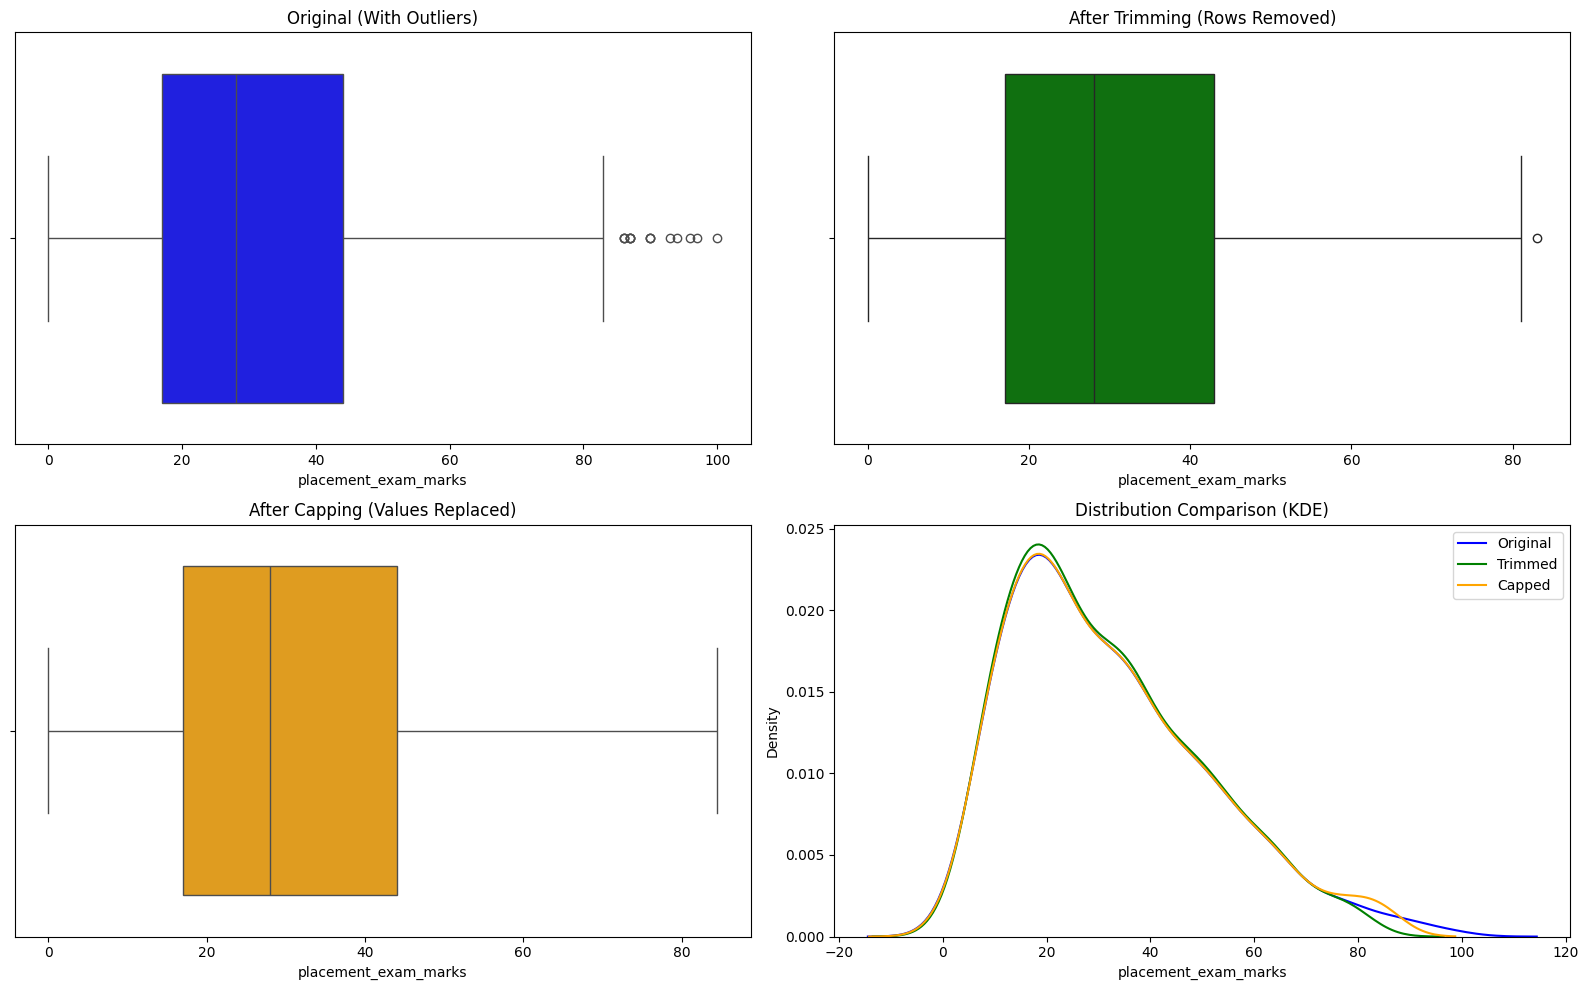

In [211]:
# Compare Trimming vs Capping Visuals
plt.figure(figsize=(16, 10))

# 1. Original Boxplot
plt.subplot(2, 2, 1)
sns.boxplot(x=df['placement_exam_marks'], color='blue')
plt.title('Original (With Outliers)')

# 2. Trimmed Boxplot
plt.subplot(2, 2, 2)
sns.boxplot(x=new_df_iqr['placement_exam_marks'], color='green')
plt.title('After Trimming (Rows Removed)')

# 3. Capped Boxplot
plt.subplot(2, 2, 3)
sns.boxplot(x=df_cap_iqr['placement_exam_marks'], color='orange')
plt.title('After Capping (Values Replaced)')

# 4. Distribution Comparison
plt.subplot(2, 2, 4)
sns.kdeplot(df['placement_exam_marks'], label='Original', color='blue')
sns.kdeplot(new_df_iqr['placement_exam_marks'], label='Trimmed', color='green')
sns.kdeplot(df_cap_iqr['placement_exam_marks'], label='Capped', color='orange')
plt.title('Distribution Comparison (KDE)')
plt.legend()

plt.tight_layout()
plt.show()

##ou'll notice that while trimming removes the tail entirely, capping 'squeezes' those extreme values into the boundary limits, which is clearly visible in the orange boxplot and KDE curve.